<a href="https://colab.research.google.com/github/Lakshya-13-04/Customer-Churn-Analysis/blob/main/Customer_churn_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving customer_churn.csv to customer_churn (1).csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set()

In [ ]:
customer = pd.read_csv('customer_churn.csv')

In [ ]:
customer.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
customer.shape

(7043, 21)

In [ ]:
customer.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
customer.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
customer.duplicated().sum()

np.int64(0)

### **1. Data Manipulation:**


In [ ]:
customer.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Extract the 5th column and store it in ‘customer_5’.
customer_5 = customer.iloc[:,4]
customer_5

,Dependents
0,No
1,No
2,No
3,No
4,No
...,...
7038,Yes
7039,Yes
7040,Yes
7041,No


In [ ]:
#Extract the 15th column and store it in ‘customer_15’
customer_15 =customer.iloc[:,14]
customer_15

,StreamingMovies
0,No
1,No
2,No
3,No
4,No
...,...
7038,Yes
7039,Yes
7040,No
7041,No


In [ ]:
#Extract all the male senior citizens whose payment method is electronic check and store the result in ‘senior_male_electronic’
senoir_male_electronic = customer[(customer['gender'] == 'Male')&(customer['SeniorCitizen'] == 1)&(customer['PaymentMethod'] == 'Electronic check')]
senoir_male_electronic

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
20,8779-QRDMV,Male,1,No,No,1,No,No phone service,DSL,No,...,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,39.65,39.65,Yes
55,1658-BYGOY,Male,1,No,No,18,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.45,1752.55,Yes
57,5067-XJQFU,Male,1,Yes,Yes,66,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,108.45,7076.35,No
78,0191-ZHSKZ,Male,1,No,No,30,Yes,No,DSL,Yes,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,74.75,2111.3,No
91,2424-WVHPL,Male,1,No,No,1,Yes,No,Fiber optic,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,74.70,74.7,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6837,6229-LSCKB,Male,1,No,No,6,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,79.70,497.6,No
6894,1400-MMYXY,Male,1,Yes,No,3,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,105.90,334.65,Yes
6914,7142-HVGBG,Male,1,Yes,No,43,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,103.00,4414.3,Yes
6967,8739-WWKDU,Male,1,No,No,25,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,89.50,2196.15,Yes


In [ ]:
# Extract all those customers whose tenure is greater than 70 months or their monthly charges is more than $100 and store the result in ‘customer_total_tenure’
customer_total_tenure = customer[(customer['tenure']>70) & (customer['MonthlyCharges'] > 100)]
customer_total_tenure

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
17,9959-WOFKT,Male,0,No,Yes,71,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),106.70,7382.25,No
59,5954-BDFSG,Female,0,No,No,72,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),107.50,7853.7,No
94,9848-JQJTX,Male,0,No,No,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Two year,Yes,Bank transfer (automatic),100.90,7459.05,No
106,6728-DKUCO,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,...,No,No,Yes,Yes,One year,Yes,Electronic check,104.15,7303.05,No
193,9680-NIAUV,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,Yes,Two year,No,Credit card (automatic),109.70,8129.3,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6859,3508-CFVZL,Female,0,No,No,71,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Mailed check,111.30,7985.9,No
6934,6257-DTAYD,Male,0,Yes,No,71,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),104.15,7365.3,No
6992,0218-QNVAS,Male,0,Yes,Yes,71,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,One year,No,Bank transfer (automatic),100.55,7113.75,No
7022,7203-OYKCT,Male,0,No,No,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Electronic check,104.95,7544.3,No


In [ ]:
#Extract all the customers whose contract is of two years, payment method  is mailed check and the value of churn is ‘Yes’ and store the result in
# ‘two_mail_yes’
two_mail_yes = customer[(customer['Contract']== 'Two year')& (customer['PaymentMethod'] == 'Mailed check')& (customer['Churn'] == 'Yes')]
two_mail_yes

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
268,6323-AYBRX,Male,0,No,No,59,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1099.6,Yes
5947,7951-QKZPL,Female,0,Yes,Yes,33,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Mailed check,24.50,740.3,Yes
6680,9412-ARGBX,Female,0,No,Yes,48,Yes,No,Fiber optic,No,...,Yes,Yes,Yes,No,Two year,Yes,Mailed check,95.50,4627.85,Yes


In [ ]:
# Extract 333 random records from the customer_churndataframe and store the result in ‘customer_333’
customer_333 = customer.sample(333)
customer_333

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4483,3873-WOSBC,Male,0,Yes,No,67,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),25.60,1784.9,No
2688,1569-TTNYJ,Male,0,Yes,No,5,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,78.75,412.1,Yes
5443,7109-MFBYV,Male,0,No,No,26,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Electronic check,45.45,1233.15,No
1575,2003-CKLOR,Male,0,No,No,66,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,99.50,6710.5,Yes
2101,2153-MREFK,Female,0,Yes,No,37,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,No,Yes,One year,Yes,Electronic check,99.20,3754.6,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2313,9154-QDGTH,Male,0,Yes,Yes,43,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,One year,Yes,Credit card (automatic),104.30,4451.85,No
6822,5389-FFVKB,Male,1,Yes,No,32,Yes,No,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Credit card (automatic),80.30,2483.05,Yes
1158,5334-JLAXU,Female,0,Yes,No,60,Yes,Yes,Fiber optic,Yes,...,No,No,No,Yes,Month-to-month,Yes,Credit card (automatic),94.10,5475.9,No
4059,3415-TAILE,Female,0,Yes,Yes,2,Yes,No,DSL,No,...,No,No,Yes,Yes,Month-to-month,No,Mailed check,65.70,134.35,Yes


In [ ]:
# Get the count of different levels from the ‘Churn’ column
customer['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


### **2. Data Visualization:**

#### Build a bar-plot for the ’InternetService’ column:
 - a. Set x-axis label to ‘Categories of Internet Service’
 - b. Set y-axis label to ‘Count of Categories’
 - c. Set the title of plot to be ‘Distribution of Internet Service’
 - d. Set the color of the bars to be ‘orange

In [ ]:
customer['InternetService'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [ ]:
customer['InternetService'].value_counts()

,count
InternetService,
Fiber optic,3096
DSL,2421
No,1526


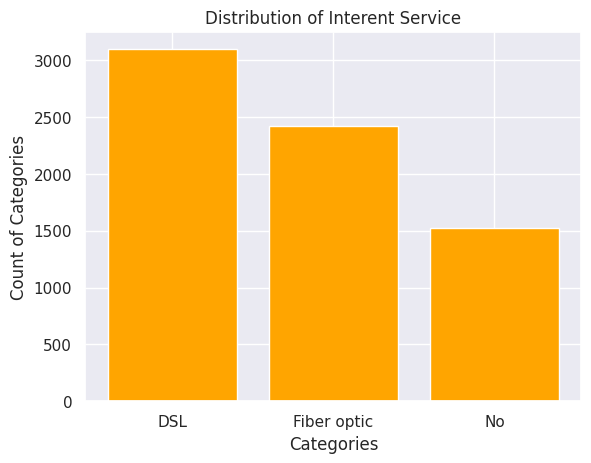

In [ ]:
plt.bar(x=customer['InternetService'].unique(), height = customer['InternetService'].value_counts(), color = 'Orange')
plt.xlabel('Categories')
plt.ylabel('Count of Categories')
plt.title('Distribution of Interent Service')
plt.show()

#### Build a histogram for the ‘tenure’ column:
 - a. Set the number of bins to be 30
 - b. Set the color of the bins to be ‘green’
 - c. Assign the title ‘Distribution of tenure’

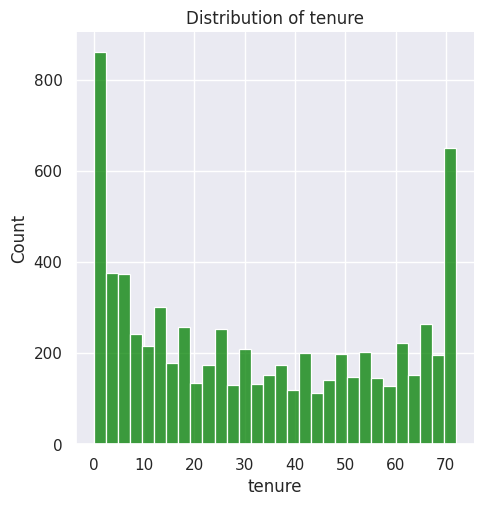

In [ ]:
sns.displot(x = 'tenure',data = customer, bins = 30,color = 'green')
plt.title('Distribution of tenure')
plt.show()

#### Build a scatter-plot between ‘MonthlyCharges’ and ‘tenure’. Map ‘MonthlyCharges’ to the y-axis and ‘tenure’ to the ‘x-axis’:
- a. Assign the points a color of ‘brown’
- b. Set the x-axis label to ‘Tenure of customer’
- c. Set the y-axis label to ‘Monthly Charges of customer’
- d. Set the title to ‘Tenure vs Monthly Charges’
- e. Build a box-plot between ‘tenure’ & ‘Contract’. Map ‘tenure’ on the y-axis &
- f. ‘Contract’ on the x-axis.

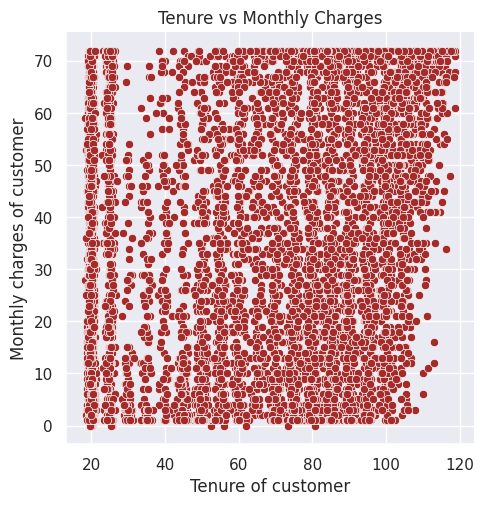

In [ ]:
sns.relplot(x = 'MonthlyCharges', y= 'tenure', data =customer, kind = 'scatter', color = 'brown')
plt.xlabel('Tenure of customer')
plt.ylabel('Monthly charges of customer')
plt.title('Tenure vs Monthly Charges')
plt.show()

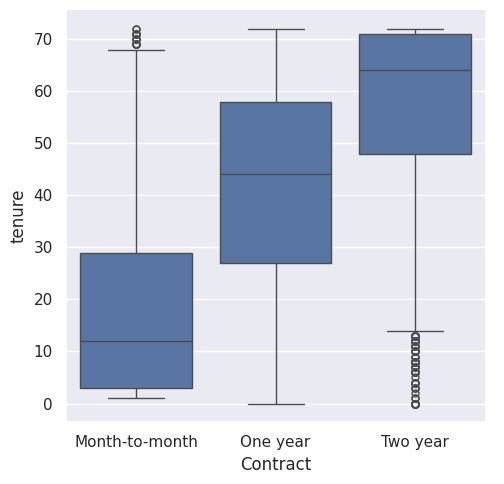

In [ ]:
sns.catplot(x = 'Contract', y = 'tenure', data = customer, kind = 'box')
plt.show()

### **3. Linear Regression:**

####  Build a simple linear model where dependent variable is ‘MonthlyCharges’ and independent variable is ‘tenure’:
- a. Divide the dataset into train and test sets in 70:30 ratio.
- b. Build the model on train set and predict the values on test set
- c. After predicting the values, find the root mean square error
- d. Find out the error in prediction & store the result in ‘error’
- e. Find the root mean square error

In [ ]:
# Import ML Libraries
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, confusion_matrix

In [ ]:
# creating two variables
X = pd.DataFrame(customer['tenure'])
y = pd.DataFrame(customer['MonthlyCharges'])

In [ ]:
customer.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


#### a. Divide the dataset into train and test sets in 70:30 ratio.

In [ ]:
# spliting the data into training dataset and testing dataset
X_train, X_test,y_train,y_test = train_test_split(X, y, test_size= 0.3, random_state= 0)

#### b. Build the model on train set and predict the values on test set

In [ ]:
# Building the model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

LinearRegression()

In [ ]:
# checking the value of intercept
lin_reg.intercept_

array([55.37598517])

In [ ]:
# checking the value of Theta
lin_reg.coef_

array([[0.29341636]])

In [ ]:
# giving the test data to lin_reg
y_pred = lin_reg.predict(X_test)

In [ ]:
y_pred

array([[60.95089608],
       [72.98096699],
       [59.1903979 ],
       ...,
       [75.62171426],
       [70.63363608],
       [65.6455579 ]])

In [ ]:
# Comparing Values with y_test
r2_score(y_test,y_pred)

0.069470028128085

#### c. After predicting the values, find the root mean square error

In [ ]:
from sklearn.metrics import mean_squared_error

In [ ]:
# Calculating mean squared error
mse = mean_squared_error(y_test,y_pred)
mse

864.0415701364655

In [ ]:
# Calculating Root mean Squared error
rmse = mse ** 0.5
rmse

29.394584027273893

### **4. Logistic Regression:**
Build a simple logistic regression model where dependent variable is ‘Churn’ and independent variable is ‘MonthlyCharges’:
- a. Divide the dataset in 65:35 ratio
- b. Build the model on train set and predict the values on test set
- c. Build the confusion matrix and get the accuracy score
- d. Build a multiple logistic regression model where dependent variable is ‘Churn’ and independent variables are ‘tenure’ and ‘MonthlyCharges’
- e. Divide the dataset in 80:20 ratio
- f. Build the model on train set and predict the values on test set
- g. Build the confusion matrix and get the accuracy score

In [ ]:
# Importing the libraries
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

#### Checking whether data is Imabalnce or not

In [ ]:
customer['MonthlyCharges'].value_counts()

,count
MonthlyCharges,
20.05,61
19.85,45
19.95,44
19.90,44
20.00,43
...,...
56.85,1
101.70,1
48.40,1


In [ ]:
customer['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [ ]:
# Making the variables
X = pd.DataFrame(customer['MonthlyCharges'])
y = pd.DataFrame(customer['Churn'])

#### a. Divide the dataset in 65:35 ratio

In [ ]:
# Dividing the dataset into training data and testing data
X_train, X_test, y_train, y_test = train_test_split(X,y,stratify = y ,test_size=0.35, random_state  = 40)

#### b. Build the model on train set and predict the values on test set

In [ ]:
log_reg = LogisticRegression()
log_reg.fit(X_train,y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [ ]:
# Checking the Intercpet Value
log_reg.intercept_

array([-2.08403847])

In [ ]:
# Checking The value of Theta
log_reg.coef_

array([[0.01557874]])

In [ ]:
# giving the test data to Log_reg
y_pred = log_reg.predict(X_test)

In [ ]:
y_pred

array(['No', 'No', 'No', ..., 'No', 'No', 'No'], dtype=object)

#### c. Build the confusion matrix and get the accuracy score

In [ ]:
#checking the Accuracy Score
accuracy_score(y_test, y_pred)

0.7347931873479319

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
# Confusion Matrxi
confusion_matrix(y_test, y_pred)

array([[1812,    0],
       [ 654,    0]])

#### d. Build a multiple logistic regression model where dependent variable is ‘Churn’ and independent variables are ‘tenure’ and ‘MonthlyCharges’
- e. Divide the dataset in 80:20 ratio
- f. Build the model on train set and predict the values on test set
- g. Build the confusion matrix and get the accuracy score

In [ ]:
# Creating the Variables
X = pd.DataFrame(customer[['tenure', 'MonthlyCharges']])
y = pd.DataFrame(customer['Churn'])

In [ ]:
# dividing The Data Set into traing data and testing Data
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, stratify = y, random_state=0)

In [ ]:
# Building The model
log_reg1 = LogisticRegression()
log_reg1.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [ ]:
# Giving the test Data
y_pred = log_reg1.predict(X_test)

In [ ]:
y_pred

array(['No', 'No', 'Yes', ..., 'No', 'No', 'Yes'], dtype=object)

In [ ]:
#  ACcuracy score and Confusion matrix
accuracy_score(y_test,y_pred)

0.7913413768630234

In [ ]:
confusion_matrix(y_test,y_pred)

array([[938,  97],
       [197, 177]])

### **5. Decision Tree:**
Build a decision tree model where dependent variable is ‘Churn’ and independent variable is ‘tenure’:
- Divide the dataset in 80:20 ratio
- Build the model on train set and predict the values on test set
- Build the confusion matrix and calculate the accuracy

In [ ]:
customer.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
customer['Churn'] = customer['Churn'].map({'No' : 0, 'Yes' : 1})

In [ ]:
X = pd.DataFrame(customer['tenure'])
y = pd.DataFrame(customer['Churn'])

In [ ]:
X_train , X_test, y_train, y_test = train_test_split(X,y, test_size= 0.20, random_state =42)

In [ ]:
DT_model = DecisionTreeClassifier()
DT_model.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = DT_model.predict(X_test)

In [ ]:
accuracy_score(y_test, y_pred)

0.7572746628814763

In [ ]:
cm = confusion_matrix(y_test, y_pred)

In [ ]:
cm

array([[951,  85],
       [257, 116]])

### 6. **Random Forest:**
Build a Random Forest model where dependent variable is ‘Churn’ and independent variables are ‘tenure’ and ‘MonthlyCharges’:
- Divide the dataset in 70:30 ratio
- Build the model on train set and predict the values on test set
- Build the confusion matrix and calculate the accuracy

In [ ]:
X = pd.DataFrame(customer[['tenure', 'MonthlyCharges']])
y = pd.DataFrame(customer['Churn'])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.30, random_state= 42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

RF_model = RandomForestClassifier()
RF_model.fit(X_train, y_train)

y_pred = RF_model.predict(X_test)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [ ]:
accuracy_score(y_test, y_pred)

0.7501183151916706

In [ ]:
cm= confusion_matrix(y_test, y_pred)

In [ ]:
cm

array([[1325,  214],
       [ 314,  260]])